# GDG Event Attendance Prediction

## Predicting Student Event Attendance Using Machine Learning

This project aims to predict whether a registered student is likely to attend a GDG event.

The model uses information such as:

- Event type
- Registration timing
- Previous event participation
- Club membership
- Event day and time
- Travel distance

The project follows a complete machine learning workflow:

**Data Collection → Data Exploration → Data Cleaning → Preprocessing → Model Training → Model Evaluation → Prediction → Risk Classification → Analytics**

## 1. Import Libraries

We begin by importing the Python libraries required for data manipulation, preprocessing, machine learning, evaluation, and visualization.

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np

Saving test.csv to test (1).csv
Saving train.csv to train (1).csv


## 2. Load the Dataset

The project uses two datasets:

- **Training dataset:** Contains historical event registration information along with the `attended` target variable.
- **Test dataset:** Contains new registrations for which attendance needs to be predicted.

We first load both CSV files and inspect their dimensions.

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Training data:", train.shape)
print("Test data:", test.shape)

Training data: (508, 10)
Test data: (100, 9)


## 3. Initial Data Inspection

Before building a machine learning model, it is important to understand the structure of the dataset.

We inspect:

- Column names
- Data types
- Number of records
- First few rows
- Missing values

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  508 non-null    object 
 1   event_type                  496 non-null    object 
 2   registration_days_before    493 non-null    float64
 3   previous_events_registered  498 non-null    float64
 4   previous_events_attended    494 non-null    float64
 5   club_member                 500 non-null    object 
 6   event_day                   499 non-null    object 
 7   event_time                  497 non-null    object 
 8   travel_distance_km          494 non-null    float64
 9   attended                    503 non-null    float64
dtypes: float64(5), object(5)
memory usage: 39.8+ KB


In [ ]:
print(train.columns.tolist())

['student_id', 'event_type', 'registration_days_before', 'previous_events_registered', 'previous_events_attended', 'club_member', 'event_day', 'event_time', 'travel_distance_km', 'attended']


In [ ]:
train.head()

,student_id,event_type,registration_days_before,previous_events_registered,previous_events_attended,club_member,event_day,event_time,travel_distance_km,attended
0,S1080,Workshop,3.0,6.0,5.0,Yes,Monday,16:00,3.8,1.0
1,S1317,Hackathon,9.0,3.0,2.0,Yes,Saturday,14:00,5.6,0.0
2,S1486,Social,0.0,7.0,5.0,Yes,Sunday,14:00,3.9,1.0
3,S1397,Competition,10.0,0.0,0.0,Yes,Monday,18:00,10.1,1.0
4,S1168,Workshop,6.0,5.0,4.0,Yes,Monday,11:00,0.7,1.0


In [ ]:
train.isnull().sum()

,0
student_id,0
event_type,12
registration_days_before,15
previous_events_registered,10
previous_events_attended,14
club_member,8
event_day,9
event_time,11
travel_distance_km,14
attended,5


## 4. Exploring Individual Features

We examine the distribution of values in each column. This helps us identify missing values, inconsistent categorical labels, and unusual numerical values that may require cleaning.

In [ ]:
for column in train.columns:
    print("\n" + "=" * 50)
    print(train[column].value_counts(dropna=False).head(20))


student_id
S1155    2
S1191    2
S1311    2
S1496    2
S1132    2
S1425    2
S1267    2
S1152    2
S1160    1
S1013    1
S1036    1
S1029    1
S1171    1
S1143    1
S1405    1
S1347    1
S1426    1
S1096    1
S1052    1
S1222    1
Name: count, dtype: int64

event_type
Workshop       140
Talk           108
Hackathon       85
Competition     83
Social          77
NaN             12
workshop         2
HACKATHON        1
Name: count, dtype: int64

registration_days_before
 11.0    43
 10.0    38
 7.0     38
 14.0    37
 1.0     36
 13.0    36
 9.0     35
 5.0     35
 6.0     33
 2.0     31
 4.0     28
 8.0     27
 0.0     25
 12.0    24
 3.0     23
 NaN     15
-2.0      1
 45.0     1
 60.0     1
-1.0      1
Name: count, dtype: int64

previous_events_registered
3.0     101
4.0      92
5.0      90
6.0      60
2.0      59
1.0      36
7.0      28
8.0      13
NaN      10
9.0       9
0.0       8
11.0      1
10.0      1
Name: count, dtype: int64

previous_events_attended
2.0    128
3.0    104
1.

## 5. Descriptive Statistics

This gives us an initial understanding of the numerical features including the mean, standard deviation, minimum, maximum, and quartiles and helps identify potentially unusual values.

In [ ]:
train.describe()

,registration_days_before,previous_events_registered,previous_events_attended,travel_distance_km,attended
count,493.000000,498.000000,494.000000,494.000000,503.000000
mean,7.460446,4.090361,2.825911,7.106478,0.630219
std,5.197028,1.947466,1.634459,8.134665,0.483226
min,-2.000000,0.000000,0.000000,0.500000,0.000000
25%,4.000000,3.000000,2.000000,3.100000,0.000000
50%,7.000000,4.000000,3.000000,5.500000,1.000000
75%,11.000000,5.000000,4.000000,9.100000,1.000000
max,60.000000,11.000000,8.000000,120.000000,1.000000


## 6. Identifying Potential Data Quality Issues

During the initial exploration, some values appeared unusual.

For example:

- Registration days outside the expected 0–14 day range
- Very large travel distances
- Previous attendance greater than previous registrations

We investigate these records before deciding how to handle them.

In [ ]:
train[
    (train["registration_days_before"] < 0) |
    (train["registration_days_before"] > 14)
]

,student_id,event_type,registration_days_before,previous_events_registered,previous_events_attended,club_member,event_day,event_time,travel_distance_km,attended
100,S1183,Social,-2.0,3.0,2.0,Yes,Friday,18:00,0.5,0.0
198,S1382,Competition,45.0,3.0,3.0,Yes,Sunday,9:00,7.4,0.0
357,S1257,Social,60.0,2.0,2.0,Yes,Saturday,14:00,1.9,0.0
392,S1301,Workshop,-1.0,6.0,3.0,Yes,Thursday,18:00,4.3,1.0


In [ ]:
train[train["travel_distance_km"] > 50]

,student_id,event_type,registration_days_before,previous_events_registered,previous_events_attended,club_member,event_day,event_time,travel_distance_km,attended
37,S1267,Competition,11.0,8.0,7.0,Yes,Tuesday,18:00,75.0,1.0
323,S1330,Workshop,10.0,3.0,3.0,Yes,Saturday,18:00,120.0,1.0
414,S1270,Hackathon,9.0,2.0,1.0,No,Friday,18:00,60.5,1.0


In [ ]:
train[
    train["previous_events_attended"] >
    train["previous_events_registered"]
]

,student_id,event_type,registration_days_before,previous_events_registered,previous_events_attended,club_member,event_day,event_time,travel_distance_km,attended
232,S1140,Social,2.0,4.0,6.0,Yes,Friday,18:00,4.5,0.0
304,S1365,Social,7.0,6.0,8.0,Yes,Tuesday,18:00,25.0,1.0
395,S1041,Workshop,8.0,5.0,6.0,Yes,Wednesday,11:00,4.5,1.0


## 7. Data Cleaning

We create copies of the original datasets so that the original data remains unchanged.

The cleaning process includes:

1. Standardizing categorical values.
2. Replacing invalid registration-day values with missing values.
3. Handling logically inconsistent previous attendance values.
4. Removing training records where the target variable is missing.

In [ ]:
train_clean = train.copy()
test_clean = test.copy()

### 7.1 Standardizing Categorical Values

Some categorical values appeared in different forms, such as:

- Workshop / workshop
- Hackathon / HACKATHON
- Yes / yes / YES

We standardize these values so that each category has one consistent representation.

In [ ]:
train_clean["event_type"] = train_clean["event_type"].str.strip().str.title()
test_clean["event_type"] = test_clean["event_type"].str.strip().str.title()

train_clean["club_member"] = train_clean["club_member"].str.strip().str.title()
test_clean["club_member"] = test_clean["club_member"].str.strip().str.title()

### 7.2 Handling Invalid Registration Values

The expected registration window is between 0 and 14 days before an event.

Values outside this range are treated as invalid and replaced with "NaN".

These missing values can then be handled later by the preprocessing pipeline.

In [ ]:
train_clean.loc[
    ~train_clean["registration_days_before"].between(0, 14),
    "registration_days_before"
] = np.nan

test_clean.loc[
    ~test_clean["registration_days_before"].between(0, 14),
    "registration_days_before"
] = np.nan

### 7.3 Handling Inconsistent Previous Attendance

A student cannot logically have attended more previous events than they registered for.

Therefore, records violating this relationship are treated as inconsistent and the "previous_events_attended" value is replaced with "NaN".

In [ ]:
invalid_attendance = (
    train_clean["previous_events_attended"] >
    train_clean["previous_events_registered"]
)

train_clean.loc[
    invalid_attendance,
    "previous_events_attended"
] = np.nan

### 7.4 Removing Records with Missing Target Values

The `attended` column is our target variable.

Rows where the target is missing cannot be used for supervised learning, so they are removed from the training dataset.

In [ ]:
train_clean = train_clean.dropna(subset=["attended"])

print("Training data after removing missing targets:")
print(train_clean.shape)

Training data after removing missing targets:
(503, 10)


## 8. Separating Features and Target

The "attended" column is the target we want to predict.

'student_id"is an identifier rather than a meaningful predictive feature, so it is excluded from the model.

The remaining columns form our input features.

In [ ]:
X = train_clean.drop(columns=["attended", "student_id"])
y = train_clean["attended"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['event_type', 'registration_days_before', 'previous_events_registered', 'previous_events_attended', 'club_member', 'event_day', 'event_time', 'travel_distance_km']

Target:
attended


In [ ]:
print(y.value_counts())

attended
1.0    317
0.0    186
Name: count, dtype: int64


In [ ]:
print(X.isnull().sum())

event_type                    12
registration_days_before      19
previous_events_registered    10
previous_events_attended      17
club_member                    8
event_day                      9
event_time                    11
travel_distance_km            14
dtype: int64


## 9. Data Preprocessing

The dataset contains both numerical and categorical features.

### Numerical features
Missing numerical values will be replaced using the median.

### Categorical features
Missing categorical values will be replaced using the most frequent category, followed by one-hot encoding.

A "Pipeline" and "ColumnTransformer" are used so that the same preprocessing steps are consistently applied during training and prediction.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
numeric_features = [
    "registration_days_before",
    "previous_events_registered",
    "previous_events_attended",
    "travel_distance_km"
]

categorical_features = [
    "event_type",
    "club_member",
    "event_day",
    "event_time"
]

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 10. Train-Validation Split

Before evaluating our models, the training data is divided into:

- **80% training data**
- **20% validation data**

We use stratification to maintain a similar proportion of attendance classes in both sets.

A fixed random state makes the experiment reproducible.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples: 402
Validation samples: 101


# 11. Initial Model Training

To determine which algorithm works best for this dataset, we experiment with four supervised learning models:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting

Rather than assuming one model will perform best, we compare their evaluation metrics.

## 11.1 Logistic Regression

Logistic Regression is used as a baseline classification model.

It estimates the probability of belonging to one of the two classes: attendance or no-show.

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_val)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Logistic Regression Results")
print("Accuracy :", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall   :", recall_score(y_val, y_pred))
print("F1 Score :", f1_score(y_val, y_pred))

Logistic Regression Results
Accuracy : 0.6336633663366337
Precision: 0.684931506849315
Recall   : 0.78125
F1 Score : 0.7299270072992701


In [ ]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))


Confusion Matrix:
[[14 23]
 [14 50]]


## 11.2 Decision Tree

A Decision Tree makes predictions by splitting the data according to feature conditions.

It is easy to interpret and provides a useful comparison with Logistic Regression.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

decision_tree_model.fit(X_train, y_train)

y_pred_dt = decision_tree_model.predict(X_val)

print("Decision Tree Results")
print("Accuracy :", accuracy_score(y_val, y_pred_dt))
print("Precision:", precision_score(y_val, y_pred_dt))
print("Recall   :", recall_score(y_val, y_pred_dt))
print("F1 Score :", f1_score(y_val, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_dt))

Decision Tree Results
Accuracy : 0.6534653465346535
Precision: 0.7164179104477612
Recall   : 0.75
F1 Score : 0.732824427480916

Confusion Matrix:
[[18 19]
 [16 48]]


## 11.3 Random Forest

Random Forest combines multiple decision trees and aggregates their predictions.

It can capture more complex relationships between the features than a single decision tree.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

n_estimators=100

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_val)

print("Random Forest Results")
print("Accuracy :", accuracy_score(y_val, y_pred_rf))
print("Precision:", precision_score(y_val, y_pred_rf))
print("Recall   :", recall_score(y_val, y_pred_rf))
print("F1 Score :", f1_score(y_val, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_rf))

Random Forest Results
Accuracy : 0.693069306930693
Precision: 0.72
Recall   : 0.84375
F1 Score : 0.7769784172661871

Confusion Matrix:
[[16 21]
 [10 54]]


## 11.4 Gradient Boosting

Gradient Boosting builds a sequence of models where each new model attempts to improve the errors made by previous models.

It provides another tree-based approach for comparison.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

gradient_boosting_model.fit(X_train, y_train)

y_pred_gb = gradient_boosting_model.predict(X_val)

print("Gradient Boosting Results")
print("Accuracy :", accuracy_score(y_val, y_pred_gb))
print("Precision:", precision_score(y_val, y_pred_gb))
print("Recall   :", recall_score(y_val, y_pred_gb))
print("F1 Score :", f1_score(y_val, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_gb))

Gradient Boosting Results
Accuracy : 0.6732673267326733
Precision: 0.7183098591549296
Recall   : 0.796875
F1 Score : 0.7555555555555555

Confusion Matrix:
[[17 20]
 [13 51]]


# 12. Re-evaluation After Data Cleaning

After completing the initial exploration and cleaning process, we repeat the model evaluation using the cleaned dataset.

This allows us to verify whether the preprocessing and data-quality improvements affect model performance.

Instead of assuming that the first results are final, we compare the four models again using the cleaned data.

In [ ]:
X_test = test_clean.drop(columns=["student_id"])

print(X_test.shape)
print(X_test.columns.tolist())

(100, 8)
['event_type', 'registration_days_before', 'previous_events_registered', 'previous_events_attended', 'club_member', 'event_day', 'event_time', 'travel_distance_km']


In [ ]:
X = train_clean.drop(columns=["student_id", "attended"])
y = train_clean["attended"]

In [ ]:
valid_rows = y.notna()

X = X[valid_rows]
y = y[valid_rows]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (503, 8)
y shape: (503,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [ ]:
model_results = {}

for name, model in models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_val)

    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    model_results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    print(f"\n{name}")
    print("-" * 30)
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))


Logistic Regression
------------------------------
Accuracy : 0.6337
Precision: 0.6849
Recall   : 0.7812
F1 Score : 0.7299

Decision Tree
------------------------------
Accuracy : 0.6535
Precision: 0.7101
Recall   : 0.7656
F1 Score : 0.7368

Random Forest
------------------------------
Accuracy : 0.6832
Precision: 0.7162
Recall   : 0.8281
F1 Score : 0.7681

Gradient Boosting
------------------------------
Accuracy : 0.6733
Precision: 0.7123
Recall   : 0.8125
F1 Score : 0.7591


In [ ]:
results_df = pd.DataFrame(model_results).T

results_df = results_df.sort_values(
    "F1 Score",
    ascending=False
)

results_df

,Accuracy,Precision,Recall,F1 Score
Random Forest,0.683168,0.716216,0.828125,0.768116
Gradient Boosting,0.673267,0.712329,0.812500,0.759124
Decision Tree,0.653465,0.710145,0.765625,0.736842
Logistic Regression,0.633663,0.684932,0.781250,0.729927


In [ ]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [ ]:
random_forest_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['registration_days_before',
                                                   'previous_events_registered',
                                                   'previous_events_attended',
                                                   'travel_distance_km']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['event_type', 'club_member',
                                                   'event_day',
                                                   'event_time'])])),
                ('model', RandomForestClassifier(random_state=42))])

# 13. Predicting Attendance for Test Data

The final Random Forest model is applied to the 100 test registrations.

For every student, we generate:

- Attendance prediction
- Attendance probability

In [ ]:
X_test = test_clean.drop(columns=["student_id"])

test_predictions = random_forest_model.predict(X_test)

test_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

In [ ]:
test_predictions = random_forest_model.predict(X_test)

In [ ]:
test_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

In [ ]:
results = test_clean[["student_id"]].copy()

results["attendance_probability"] = test_probabilities
results["prediction"] = test_predictions

results.head(10)

,student_id,attendance_probability,prediction
0,S1379,0.90,1.0
1,S1425,0.91,1.0
2,S1273,0.11,0.0
3,S1028,0.19,0.0
4,S1259,0.80,1.0
5,S1409,0.90,1.0
6,S1494,0.91,1.0
7,S1204,0.61,1.0
8,S1166,0.80,1.0
9,S1388,0.90,1.0


## 13.1 Attendance Probability and Risk Level

Instead of providing only a binary prediction, we also calculate the probability that a student will attend.

The probability is converted into three practical risk categories:

- **High likelihood:** probability ≥ 80%
- **Medium likelihood:** probability between 80% and 50%
- **High no-show risk:** probability < 40%

This provides organizers with more information than a simple Attend/No-show prediction.

In [ ]:
def risk_category(probability):
    if probability >= 0.80:
        return "High likelihood"
    elif probability >= 0.50:
        return "Medium likelihood"
    else:
        return "High no-show risk"

results["risk_level"] = results["attendance_probability"].apply(risk_category)

In [ ]:
results["attendance_probability_percent"] = (
    results["attendance_probability"] * 100
).round(1)

results.head(10)

,student_id,attendance_probability,prediction,risk_level,attendance_probability_percent
0,S1379,0.90,1.0,High likelihood,90.0
1,S1425,0.91,1.0,High likelihood,91.0
2,S1273,0.11,0.0,High no-show risk,11.0
3,S1028,0.19,0.0,High no-show risk,19.0
4,S1259,0.80,1.0,High likelihood,80.0
5,S1409,0.90,1.0,High likelihood,90.0
6,S1494,0.91,1.0,High likelihood,91.0
7,S1204,0.61,1.0,Medium likelihood,61.0
8,S1166,0.80,1.0,High likelihood,80.0
9,S1388,0.90,1.0,High likelihood,90.0


In [ ]:
print(results["risk_level"].value_counts())

risk_level
High likelihood      61
High no-show risk    38
Medium likelihood     1
Name: count, dtype: int64


In [ ]:
print(results["prediction"].value_counts())

prediction
1.0    62
0.0    38
Name: count, dtype: int64


In [ ]:
results["attendance_probability"].describe()

,attendance_probability
count,100.000000
mean,0.624900
std,0.327511
min,0.040000
25%,0.250000
50%,0.815000
75%,0.900000
max,0.970000


In [ ]:
results["attendance_probability"].sort_values().to_list()

[0.04,
 0.09,
 0.11,
 0.12,
 0.13,
 0.13,
 0.14,
 0.14,
 0.15,
 0.16,
 0.16,
 0.16,
 0.18,
 0.19,
 0.19,
 0.2,
 0.2,
 0.2,
 0.22,
 0.22,
 0.22,
 0.23,
 0.23,
 0.25,
 0.25,
 0.25,
 0.26,
 0.27,
 0.27,
 0.28,
 0.29,
 0.3,
 0.32,
 0.34,
 0.34,
 0.35,
 0.36,
 0.39,
 0.61,
 0.71,
 0.75,
 0.76,
 0.78,
 0.79,
 0.79,
 0.8,
 0.8,
 0.8,
 0.81,
 0.81,
 0.82,
 0.82,
 0.83,
 0.83,
 0.84,
 0.85,
 0.85,
 0.85,
 0.85,
 0.85,
 0.86,
 0.87,
 0.87,
 0.88,
 0.88,
 0.88,
 0.88,
 0.89,
 0.89,
 0.89,
 0.89,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.91,
 0.91,
 0.91,
 0.91,
 0.92,
 0.92,
 0.92,
 0.92,
 0.92,
 0.93,
 0.93,
 0.93,
 0.93,
 0.93,
 0.93,
 0.95,
 0.95,
 0.95,
 0.96,
 0.96,
 0.96,
 0.96,
 0.97]

In [ ]:
results["prediction_label"] = results["prediction"].map({
    1.0: "Attend",
    0.0: "No-show"
})

# 14. Why This Prediction? — Feature Importance

Random Forest provides feature importance scores that indicate how much each input feature contributed to the model's decisions.

This is a model-level explanation and should not be interpreted as proof that a feature directly causes attendance.

In [ ]:
rf_model = random_forest_model.named_steps["model"]

importances = rf_model.feature_importances_

print(importances)

[0.16069098 0.10484783 0.08581825 0.1889563  0.02222837 0.00213574
 0.02040894 0.02083474 0.02305909 0.03181578 0.00063215 0.02755113
 0.00020054 0.0211747  0.00175009 0.02854554 0.0257517  0.0267407
 0.0225966  0.02241372 0.0192429  0.02020344 0.0220292  0.02407746
 0.02341493 0.02821185 0.02466732]


In [ ]:
feature_names = random_forest_model.named_steps[
    "preprocessor"
].get_feature_names_out()

print(len(feature_names))
print(feature_names)

27
['num__registration_days_before' 'num__previous_events_registered'
 'num__previous_events_attended' 'num__travel_distance_km'
 'cat__event_type_Competition' 'cat__event_type_HACKATHON'
 'cat__event_type_Hackathon' 'cat__event_type_Social'
 'cat__event_type_Talk' 'cat__event_type_Workshop'
 'cat__event_type_workshop' 'cat__club_member_No' 'cat__club_member_YES'
 'cat__club_member_Yes' 'cat__club_member_yes' 'cat__event_day_Friday'
 'cat__event_day_Monday' 'cat__event_day_Saturday' 'cat__event_day_Sunday'
 'cat__event_day_Thursday' 'cat__event_day_Tuesday'
 'cat__event_day_Wednesday' 'cat__event_time_11:00'
 'cat__event_time_14:00' 'cat__event_time_16:00' 'cat__event_time_18:00'
 'cat__event_time_9:00']


In [ ]:
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
3,num__travel_distance_km,0.188956
0,num__registration_days_before,0.160691
1,num__previous_events_registered,0.104848
2,num__previous_events_attended,0.085818
9,cat__event_type_Workshop,0.031816
15,cat__event_day_Friday,0.028546
25,cat__event_time_18:00,0.028212
11,cat__club_member_No,0.027551
17,cat__event_day_Saturday,0.026741
16,cat__event_day_Monday,0.025752


In [ ]:
results = test_clean[["student_id"]].copy()

results["attendance_probability"] = test_probabilities
results["prediction"] = test_predictions

In [ ]:
results["prediction_label"] = results["prediction"].map({
    1.0: "Attend",
    0.0: "No-show"
})

results["attendance_probability_percent"] = (
    results["attendance_probability"] * 100
).round(1)

results.head(10)

,student_id,attendance_probability,prediction,risk_level,prediction_label,attendance_probability_percent
0,S1379,0.96,1.0,High likelihood,Attend,96.0
1,S1425,0.92,1.0,High likelihood,Attend,92.0
2,S1273,0.08,0.0,High no-show risk,No-show,8.0
3,S1028,0.19,0.0,High no-show risk,No-show,19.0
4,S1259,0.81,1.0,High likelihood,Attend,81.0
5,S1409,0.89,1.0,High likelihood,Attend,89.0
6,S1494,0.87,1.0,High likelihood,Attend,87.0
7,S1204,0.57,1.0,Medium likelihood,Attend,57.0
8,S1166,0.80,1.0,High likelihood,Attend,80.0
9,S1388,0.92,1.0,High likelihood,Attend,92.0


In [ ]:
rf_model = random_forest_model.named_steps["model"]

importances = rf_model.feature_importances_

feature_names = random_forest_model.named_steps[
    "preprocessor"
].get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
3,num__travel_distance_km,0.180068
0,num__registration_days_before,0.164924
1,num__previous_events_registered,0.104029
2,num__previous_events_attended,0.092068
8,cat__event_type_Workshop,0.034477
21,cat__event_time_18:00,0.030622
12,cat__event_day_Monday,0.026424
13,cat__event_day_Saturday,0.026189
10,cat__club_member_Yes,0.025807
19,cat__event_time_14:00,0.025693


In [ ]:
feature_importance["feature_clean"] = (
    feature_importance["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

feature_importance[["feature_clean", "importance"]].head(10)

,feature_clean,importance
3,travel_distance_km,0.180068
0,registration_days_before,0.164924
1,previous_events_registered,0.104029
2,previous_events_attended,0.092068
8,event_type_Workshop,0.034477
21,event_time_18:00,0.030622
12,event_day_Monday,0.026424
13,event_day_Saturday,0.026189
10,club_member_Yes,0.025807
19,event_time_14:00,0.025693


# 15. Organizer Analytics

The model predictions can also be summarized at an event level to provide organizers with a quick overview.

The dashboard statistics include:

- Total registrations
- Predicted attendees
- Predicted no-shows
- Average attendance probability
- Risk distribution

In [ ]:
total_students = len(results)

predicted_attendees = (results["prediction"] == 1).sum()
predicted_no_shows = (results["prediction"] == 0).sum()

average_probability = results["attendance_probability"].mean()

print("Total registrations:", total_students)
print("Predicted attendees:", predicted_attendees)
print("Predicted no-shows:", predicted_no_shows)
print("Average attendance probability:",
      round(average_probability * 100, 2), "%")

Total registrations: 100
Predicted attendees: 62
Predicted no-shows: 38
Average attendance probability: 62.98 %


In [ ]:
print("\nRisk Distribution:")
print(results["risk_level"].value_counts())


Risk Distribution:
risk_level
High likelihood      61
High no-show risk    38
Medium likelihood     1
Name: count, dtype: int64


In [ ]:
results.to_csv("attendance_predictions.csv", index=False)

print("Prediction file saved successfully!")
print(results.shape)

Prediction file saved successfully!
(100, 6)


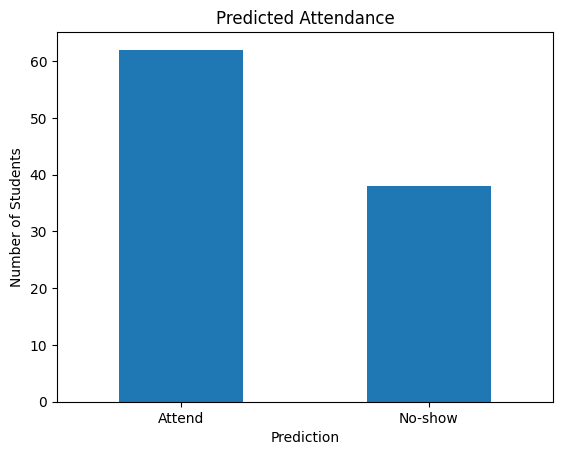

In [ ]:
import matplotlib.pyplot as plt

prediction_counts = results["prediction_label"].value_counts()

prediction_counts.plot(kind="bar")

plt.title("Predicted Attendance")
plt.xlabel("Prediction")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

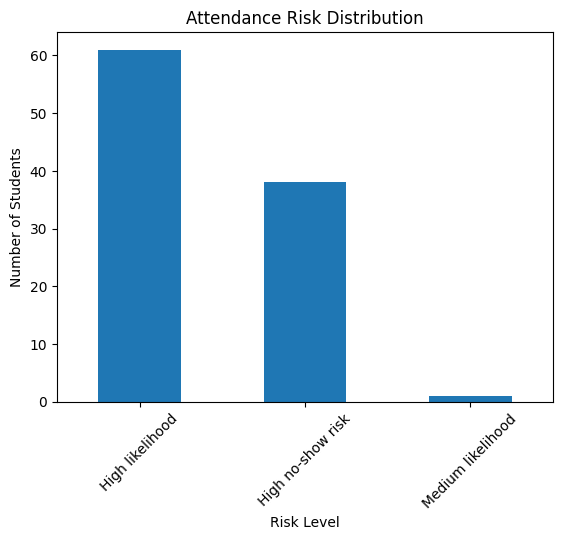

In [ ]:
risk_counts = results["risk_level"].value_counts()

risk_counts.plot(kind="bar")

plt.title("Attendance Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)
plt.show()

# 16. Visual Analytics

Visualizations make the model's results easier to interpret.

We create three main views:

1. Predicted attendance distribution
2. Attendance risk distribution
3. Top features influencing model predictions

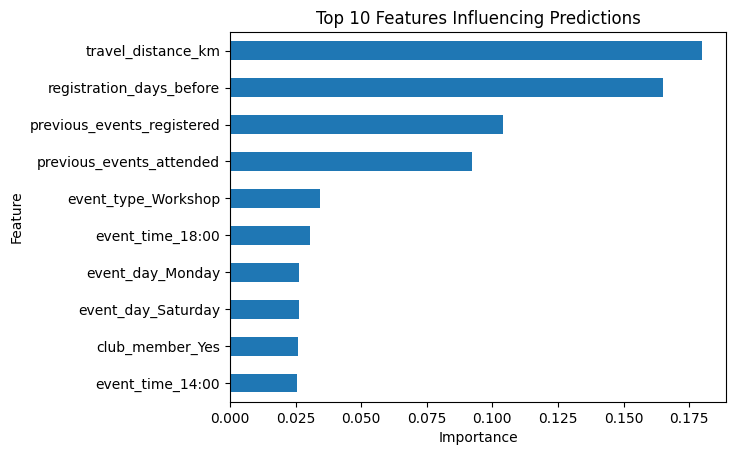

In [ ]:
top_features = feature_importance.head(10).sort_values(
    "importance"
)

top_features.plot(
    x="feature_clean",
    y="importance",
    kind="barh",
    legend=False
)

plt.title("Top 10 Features Influencing Predictions")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
results.to_csv("attendance_predictions.csv", index=False)

In [ ]:
import os

print(os.path.exists("attendance_predictions.csv"))

True


In [ ]:
import joblib

joblib.dump(random_forest_model, "attendance_model.pkl")

print("Model saved successfully!")

Model saved successfully!


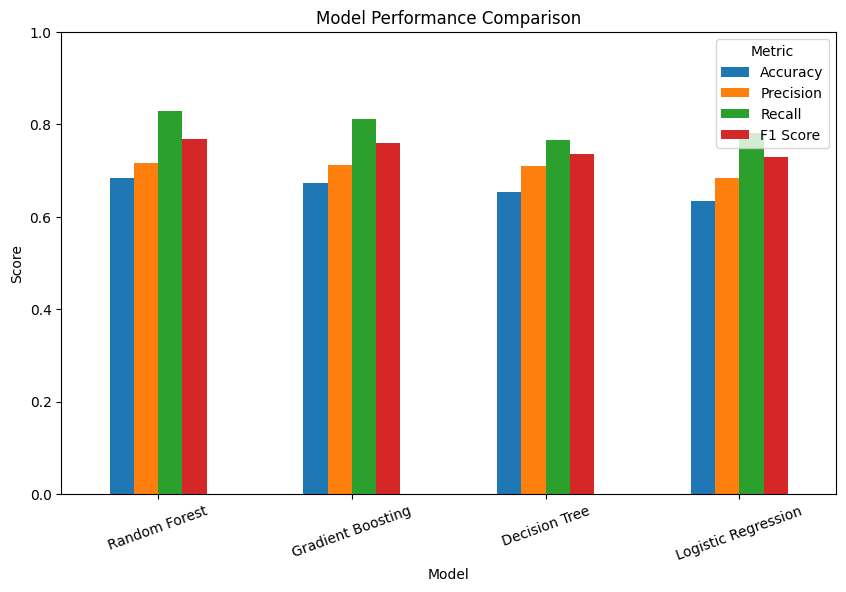

In [ ]:
results_df.plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.show()

# 17. Conclusion

This project developed a machine learning system for predicting student attendance at GDG events.

The workflow included data exploration, data cleaning, preprocessing, model experimentation, evaluation, and final prediction.

Four classification algorithms were evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Random Forest achieved the best overall performance on the validation dataset:

- **Accuracy:** 68.32%
- **Precision:** 71.62%
- **Recall:** 82.81%
- **F1-score:** 76.81%

The final model was trained on all valid training records and used to predict attendance for 100 test registrations.

The system provides both a binary attendance prediction and an attendance probability, which is further converted into practical risk categories.

The feature-importance analysis also provides insight into which factors the Random Forest model relied on most heavily, with travel distance, registration timing, and previous event participation among the most important features.

Overall, the project demonstrates a complete end-to-end machine learning workflow and shows how attendance predictions can be transformed into useful information for event organizers.